# Decision Tree

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    run_stratified_cv,
    run_seed_sweep, SweepResult,
    print_sweep_classification_report,
    print_sweep_performance_summary,
    print_sweep_error_patterns,
    plot_posterior_violins,
    plot_sweep_f1_bar, plot_sweep_confusion_matrix, plot_sweep_feature_importances,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

# Decision trees split on raw thresholds — log transforms and clipping are not needed.
# StandardScaler is passed for interface consistency but does not affect tree behaviour.
X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df,
    scaler=StandardScaler(),
    smote_variant="standard",
)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

## Training

In [3]:
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
}

grid_dt = run_grid_search(
    DecisionTreeClassifier(class_weight=class_weight_dict, random_state=42),
    param_grid,
    X_train_bal,
    y_train_bal,
)
dt = grid_dt.best_estimator_

y_pred_dt = dt.predict(X_test_scaled)
y_prob_dt  = dt.predict_proba(X_test_scaled)

print("Decision Tree training complete.")
print(f"Best max_depth:        {grid_dt.best_params_['max_depth']}")
print(f"Best min_samples_leaf: {grid_dt.best_params_['min_samples_leaf']}")
print(f"Best criterion:        {grid_dt.best_params_['criterion']}")
print(f"Best CV F1 Macro:      {grid_dt.best_score_:.4f}")
print(f"Actual tree depth:     {dt.get_depth()}")
print(f"Number of leaves:      {dt.get_n_leaves()}")

Decision Tree training complete.
Best max_depth:        5
Best min_samples_leaf: 1
Best criterion:        entropy
Best CV F1 Macro:      0.9823
Actual tree depth:     5
Number of leaves:      11


### Seed-Sweep Evaluation

Grid search above tuned hyperparameters on `random_state=42` only. The single test F1 macro from that one split is a noisy estimate when the minority test classes are tiny (6 mesoplanet, 8 psychroplanet samples). Re-evaluate with the same tuned hyperparameters across 50 random splits to estimate expected performance — and capture per-seed confusion matrices and feature importances for downstream aggregated diagnostics.

In [4]:
sweep_dt = run_seed_sweep(
    lambda cw: DecisionTreeClassifier(
        **grid_dt.best_params_,
        class_weight=cw, random_state=42,
    ),
    df,
    n_seeds=50,
    model_name="DT",
    save_csv="sweep_dtree.csv",
    save_pickle="sweep_dtree.pkl",   # for re-plotting without re-computing
)

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/si

DT — 50-seed sweep
  F1 macro:    0.7229 ± 0.0649  (SEM 0.0092, min 0.5558, max 0.8776)
  F1 weighted: 0.9860 ± 0.0042
  Captured feature importances for 50 seeds.
  F1 DataFrame saved to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/basic_models/../data/output/seed_sweep_results/sweep_dtree.csv
  Full SweepResult pickled to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/basic_models/../data/output/seed_sweep_results/sweep_dtree.pkl


## Modeling
### DIAGNOSTIC PLOT 1: Feature Importances

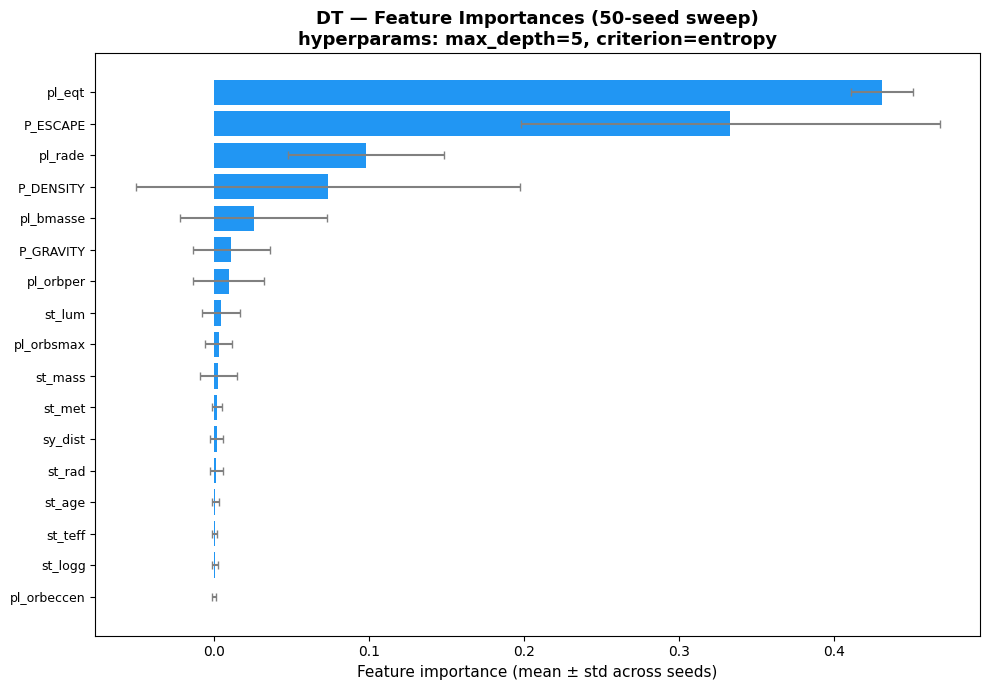

In [5]:
plot_sweep_feature_importances(
    sweep_dt,
    subtitle=f"hyperparams: max_depth={grid_dt.best_params_['max_depth']}, "
             f"criterion={grid_dt.best_params_['criterion']}",
)

### DIAGNOSTIC PLOT 2: Depth vs CV F1 Macro

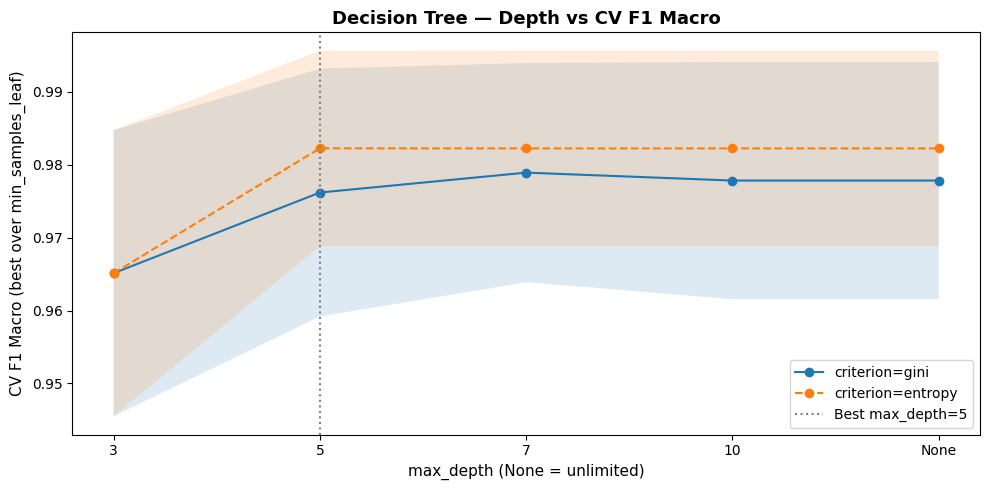

↑ Each point = best score across all min_samples_leaf values at that depth.
  Shallow trees underfit; deep trees overfit the balanced training set.
  None = no depth limit — the tree grows until leaves are pure.


In [6]:
results_df = pd.DataFrame(grid_dt.cv_results_)
depth_labels = [str(d) if d is not None else "None" for d in [3, 5, 7, 10, None]]
depth_vals   = [3, 5, 7, 10, None]

fig, ax = plt.subplots(figsize=(10, 5))
for criterion, ls in [("gini", "-"), ("entropy", "--")]:
    means, stds = [], []
    for d in depth_vals:
        mask = (
            (results_df["param_criterion"] == criterion) &
            (results_df["param_max_depth"].apply(lambda x: x == d))
        )
        sub = results_df[mask]
        means.append(sub["mean_test_score"].max())
        stds.append(sub.loc[sub["mean_test_score"].idxmax(), "std_test_score"])
    means, stds = np.array(means), np.array(stds)
    ax.plot(range(len(depth_labels)), means, marker="o", ls=ls, label=f"criterion={criterion}")
    ax.fill_between(range(len(depth_labels)), means - stds, means + stds, alpha=0.15)

best_d = str(grid_dt.best_params_["max_depth"])
best_x = depth_labels.index(best_d)
ax.axvline(best_x, color="gray", ls=":", lw=1.5, label=f"Best max_depth={best_d}")
ax.set_xticks(range(len(depth_labels)))
ax.set_xticklabels(depth_labels, fontsize=10)
ax.set_xlabel("max_depth (None = unlimited)", fontsize=11)
ax.set_ylabel("CV F1 Macro (best over min_samples_leaf)", fontsize=11)
ax.set_title("Decision Tree — Depth vs CV F1 Macro", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("dt_depth_sensitivity")
plt.show()

print("↑ Each point = best score across all min_samples_leaf values at that depth.")
print("  Shallow trees underfit; deep trees overfit the balanced training set.")
print("  None = no depth limit — the tree grows until leaves are pure.")

### DIAGNOSTIC PLOT 3: Tree Structure (depth ≤ 5)

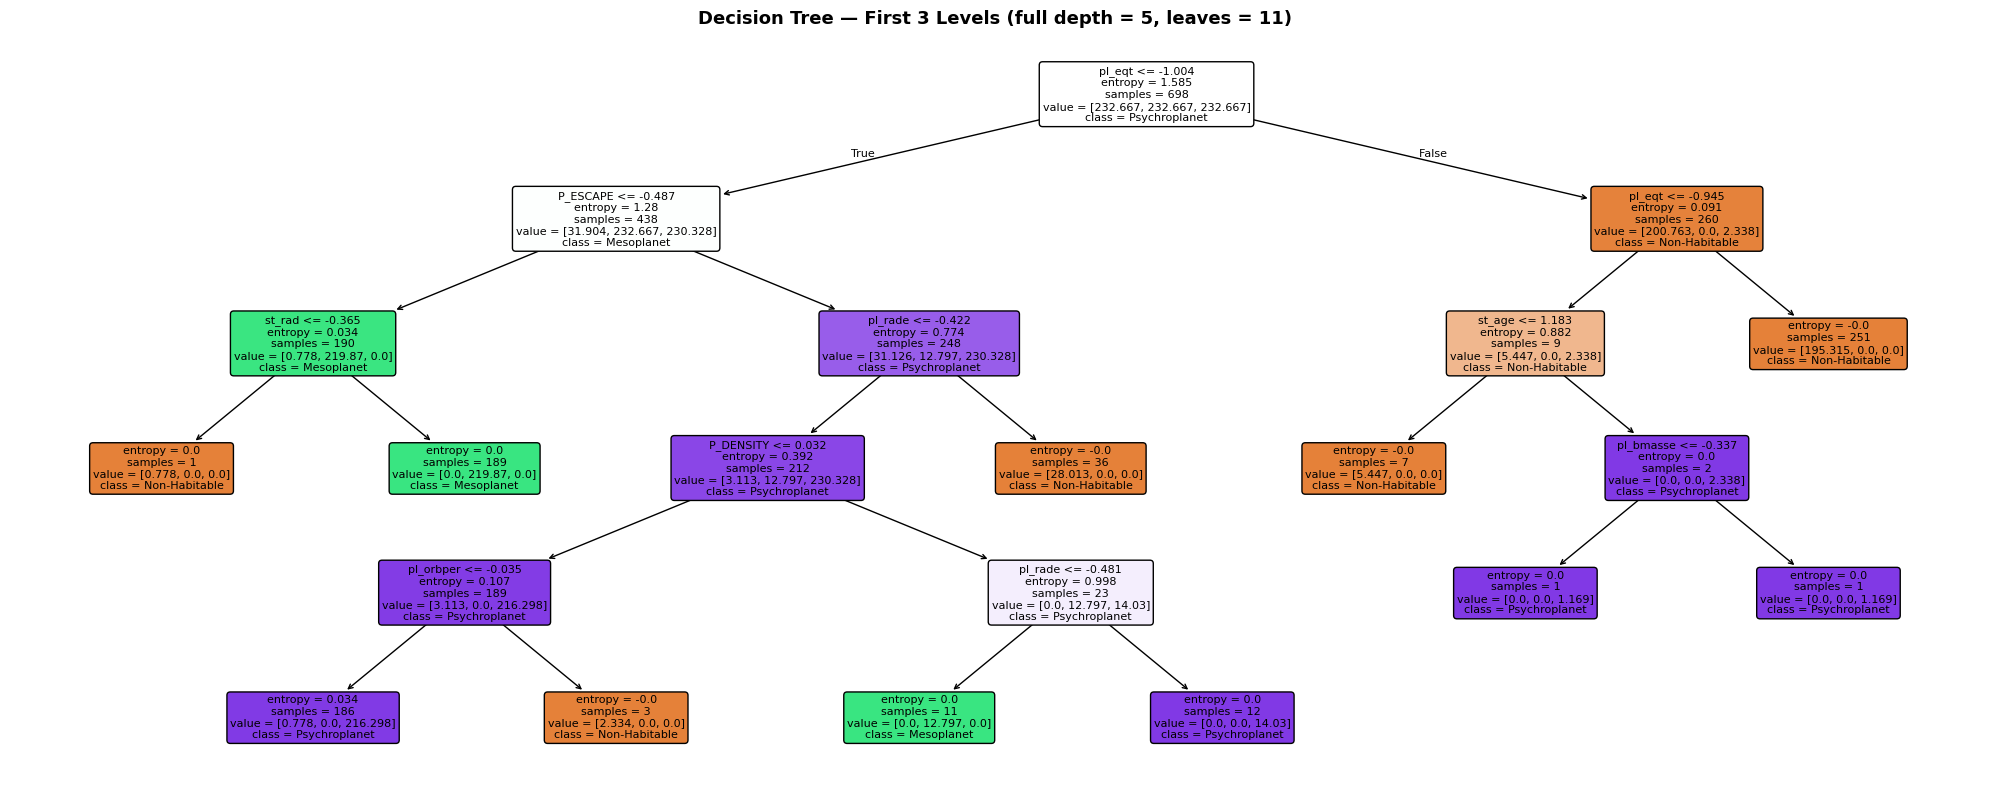

↑ Each node shows: split feature/threshold, Gini impurity, sample count, class distribution.
  Colour intensity = class purity (darker = more confident split).
  Only the first 3 levels shown — the full tree has 5 levels and 11 leaves.


In [7]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt,
    max_depth=5,
    feature_names=FEATURES,
    class_names=class_names,
    filled=True,
    impurity=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
ax.set_title(
    f"Decision Tree — First 3 Levels (full depth = {dt.get_depth()}, leaves = {dt.get_n_leaves()})",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
save_plot("dt_tree_structure")
plt.show()

print("↑ Each node shows: split feature/threshold, Gini impurity, sample count, class distribution.")
print("  Colour intensity = class purity (darker = more confident split).")
print(f"  Only the first 3 levels shown — the full tree has {dt.get_depth()} levels and {dt.get_n_leaves()} leaves.")

## Metrics
### Classification Report + F1 Scores

DT — Classification Report (50-seed sweep)
Class               F1 mean     F1 std     F1 min     F1 max
----------------------------------------------------------------
Non-Habitable        0.9912     0.0033     0.9810     0.9964
Mesoplanet           0.6838     0.1345     0.3077     1.0000
Psychroplanet        0.4936     0.1079     0.2273     0.7000
----------------------------------------------------------------
Macro avg            0.7229     0.0649     0.5558     0.8776
Weighted avg         0.9860     0.0042     0.9739     0.9938

5-Fold CV F1 Macro: 0.9693 ± 0.0228

DT — Performance Summary (50-seed sweep)

Per-class Precision and Recall (mean ± std)
                 Precision            Recall              
Non-Habitable    0.9993 ± 0.0008    0.9833 ± 0.0063
Mesoplanet       0.5759 ± 0.1500    0.8833 ± 0.1624
Psychroplanet    0.3491 ± 0.0966    0.8850 ± 0.1233
----------------------------------------------------------------
Macro avg        0.6414 ± 0.0635    0.9172 ± 0.0697
Weigh

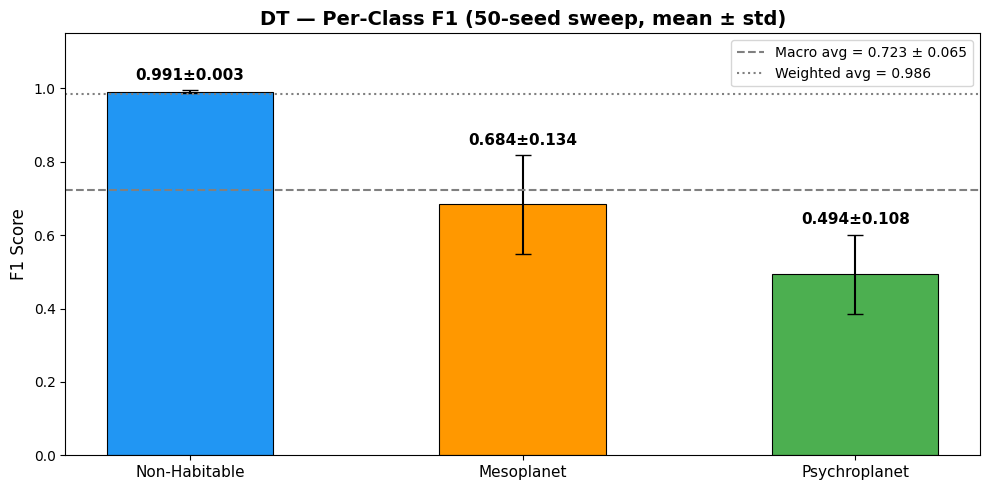

In [8]:
# Per-class F1 with mean ± std from the seed sweep
print_sweep_classification_report(sweep_dt)

# 5-fold CV on the balanced training set — orthogonal to sweep variance,
# measures within-seed tuning stability (different question).
cv_scores_dt = run_stratified_cv(dt, X_train_bal, y_train_bal)

# Cross-model comparison metrics: per-class P/R + aggregate robustness scores
# (MCC, balanced accuracy, minority F1 macro)
print_sweep_performance_summary(sweep_dt)

# Per-class bar chart with error bars from the sweep distribution
plot_sweep_f1_bar(sweep_dt)

### Confusion Matrices (Counts + Normalized)

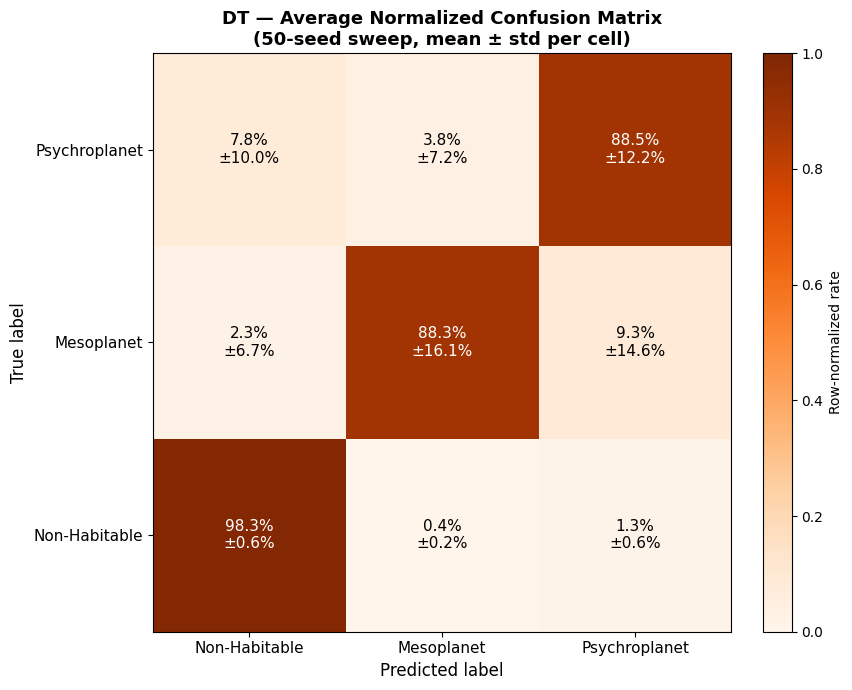

Key error patterns (50-seed sweep):
  Non-Habitable → predicted Mesoplanet: 4.16 ± 2.62 per split  (0.4% ± 0.2% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 14.20 ± 6.54 per split  (1.3% ± 0.6% of true Non-Habitable)
  Mesoplanet → predicted Non-Habitable: 0.14 ± 0.40 per split  (2.3% ± 6.7% of true Mesoplanet)
  Mesoplanet → predicted Psychroplanet: 0.56 ± 0.88 per split  (9.3% ± 14.6% of true Mesoplanet)
  Psychroplanet → predicted Non-Habitable: 0.62 ± 0.80 per split  (7.8% ± 10.0% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 0.30 ± 0.57 per split  (3.8% ± 7.2% of true Psychroplanet)


In [9]:
# Average row-normalized CM across all 50 seeds, annotated per-cell with std
plot_sweep_confusion_matrix(sweep_dt)

# Off-diagonal patterns: per-split count and per-class rate, both mean ± std
print_sweep_error_patterns(sweep_dt)

## Interpretation: